# OpenCV_第2回：画像の基本処理と描画

## 基本的な画像処理

・画像のピクセル操作  
・画像のサイズ変更  
・トリミング  
・反転  


In [1]:
import os
import cv2
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

matplotlib.rcParams['figure.figsize'] = (9.0, 9.0)
%matplotlib inline

### 画像のダウンロード

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/rys6f1vprily2bg/opencv_bootcamp_assets_NB2.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB2.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)   

## ピクセルの操作

Numpy行列内の任意のピクセルにアクセスするにはmatrix[r, c]のような行列表記をする。rは行番号、cは列番号を表す。（行列のインデックスは0から始まる）

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

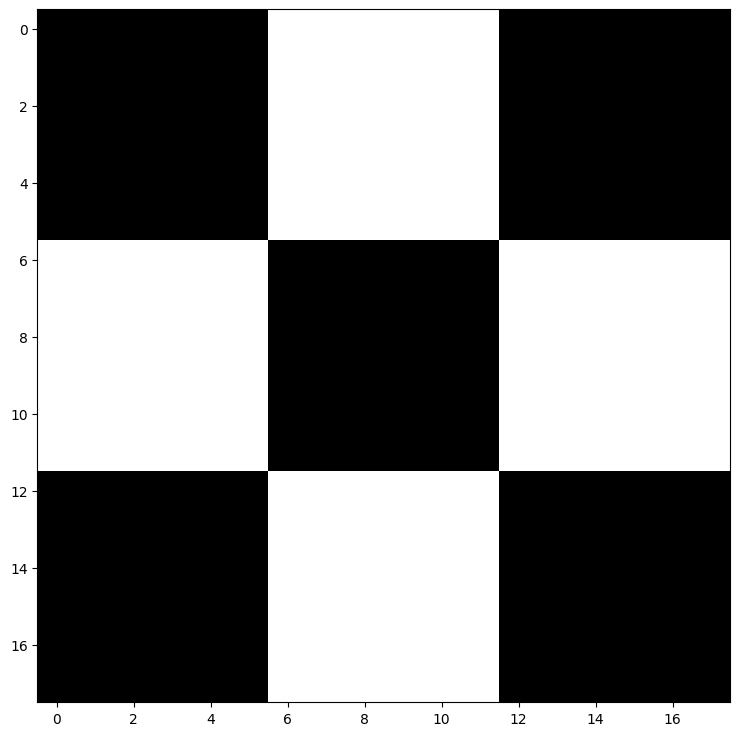

In [4]:
# 第1回でも扱った白黒画像を表示
cb_img = cv2.imread("checkerboard_18x18.png", 0)

plt.imshow(cb_img, cmap="gray")
print(cb_img)

In [5]:
# ピクセルへのアクセス
# 最初のブラックボックス(黒い領域)の一番最初のピクセル
print(cb_img[0, 0])
# 最初のブラックボックスの隣の白いボックスの一番最初のピクセル
print(cb_img[0, 6])

0
255


[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0 200 200   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0 200 200   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

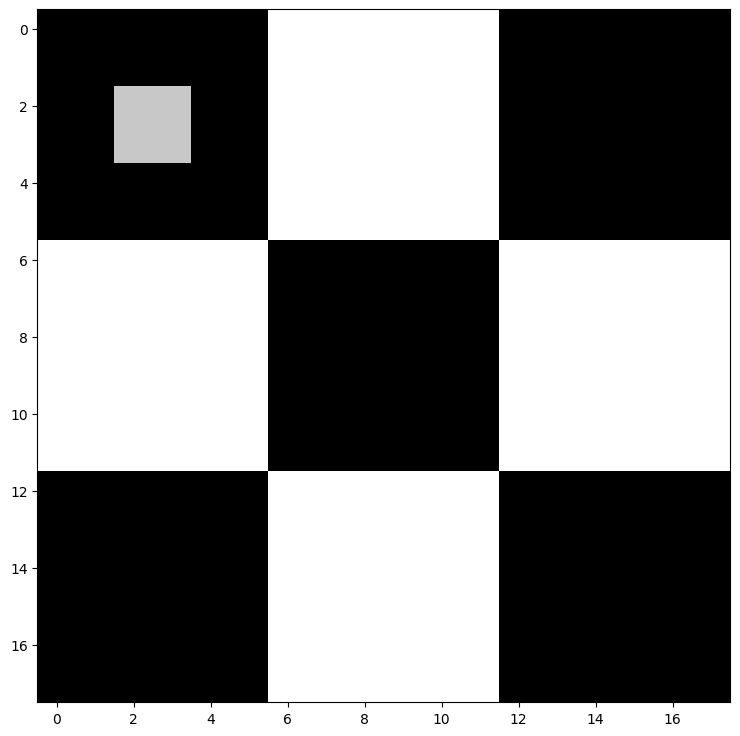

In [6]:
# ピクセルの書き換え  
cb_img_copy = cb_img.copy()
cb_img_copy[2, 2] = 200
cb_img_copy[2, 3] = 200
cb_img_copy[3, 2] = 200
cb_img_copy[3, 3] = 200

# 上記コードは以下と同じ。
# cb_img_copy[2:3,2:3] = 200

plt.imshow(cb_img_copy, cmap="gray")
print(cb_img_copy)

## 画像の切り抜き

トリミングは特定のピクセル領域を選択するだけで簡単にできる。

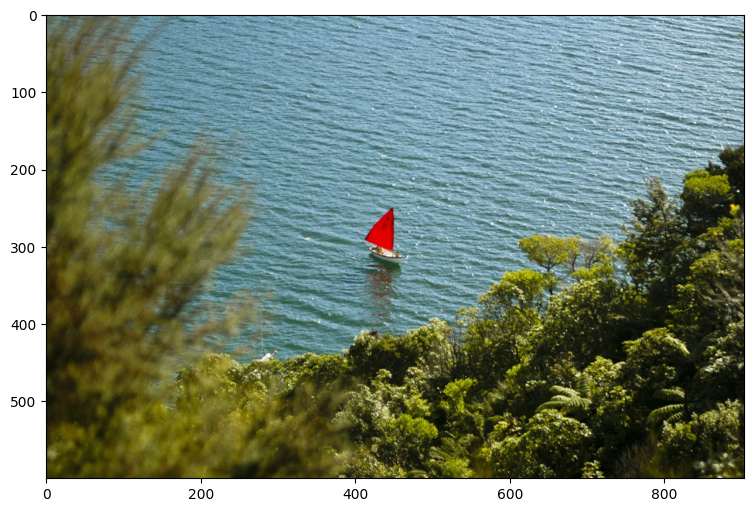

In [7]:
img_NZ_bgr = cv2.imread("New_Zealand_Boat.jpg", cv2.IMREAD_COLOR)
img_NZ_rgb = img_NZ_bgr[:, :, ::-1]

plt.imshow(img_NZ_rgb)

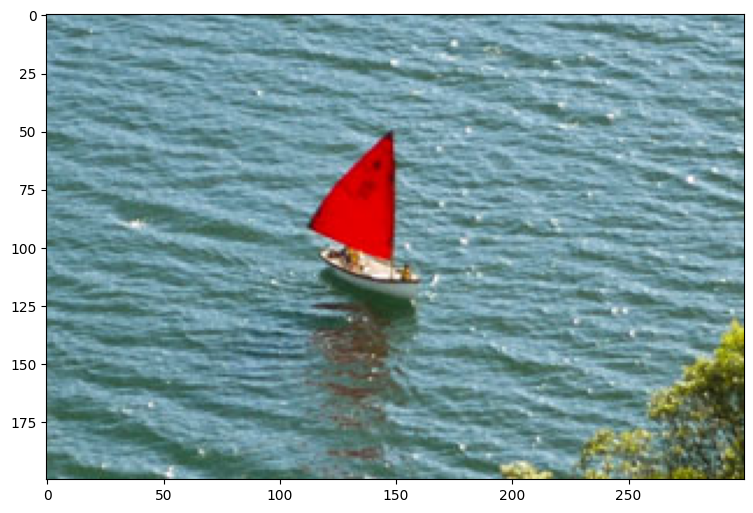

In [8]:
cropped_region = img_NZ_rgb[200:400, 300:600]

plt.imshow(cropped_region)

## 画像のサイズ変更

`cv2.resize(src, dsize, fx, fy, interpolation)`  

必須の引数  
・src：入力画像  
・dsize：出力画像サイズ（(W, H))

任意  
・fx：水平方向の拡大/縮小率。0のときは (double)dsize.width / src.cols として計算される（dsizeが決まってれば倍率は勝手に決まるってこと）。  
・fy：垂直方向の拡大/縮小率。0のときは (double)dsize.height / src.rows として計算されます。 
・interpolation：補間方法。縮小時はcv2.INTER_AREAを指定すると画質が保たれる。

出力画像のサイズはdsizeまたは、src.size()、fx、fyから計算されたサイズになる。  

dsizeとfx/fyはどちらか一方を使う関係にある。  
dsize：サイズを直接指定  
fx/fy：倍率を指定。この場合、dsizeにはNoneを入力。

### ①fx/fyを使用して拡大宿曜率を指定する

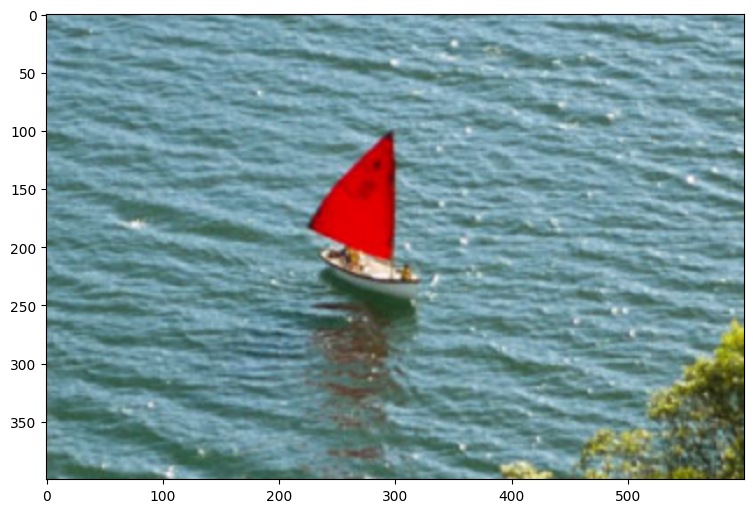

In [9]:
resized_cropped_region_2x = cv2.resize(cropped_region, None, fx=2, fy=2)

plt.imshow(resized_cropped_region_2x)

### ②dsizeで出力サイズを指定する

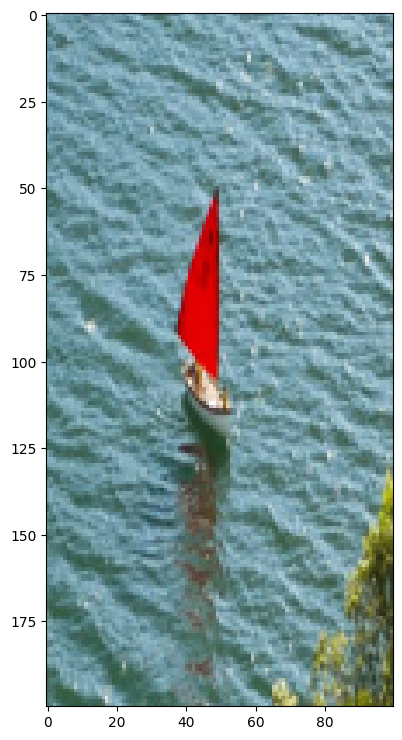

In [10]:
desired_width = 100
desired_height = 200
dim = (desired_width, desired_height)

resized_cropped_region = cv2.resize(cropped_region, dsize=dim, interpolation=cv2.INTER_AREA)
plt.imshow(resized_cropped_region)

### アスペクト比(幅と高さの比)を維持してサイズを変更する

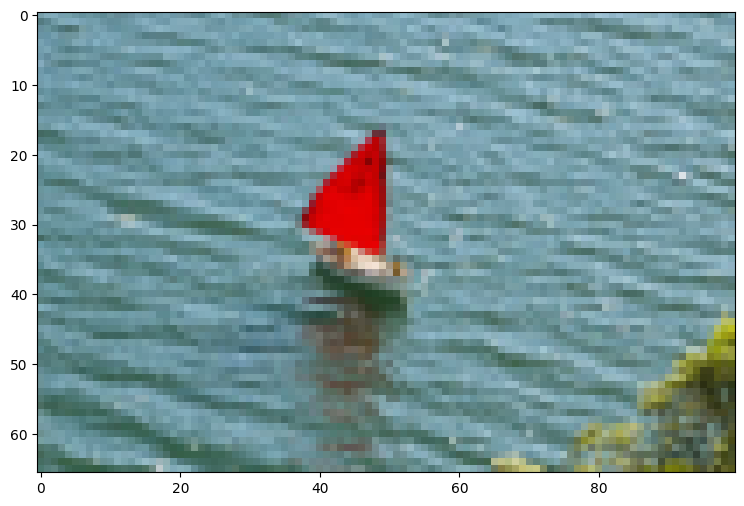

In [11]:
desired_width = 100
# 縮小率の計算
# cropped_region.shape:(H, W, C)
# 目標の幅/元の幅=縮小率
aspect_ratio = desired_width / cropped_region.shape[1]
desired_height = int(cropped_region.shape[0] * aspect_ratio)
dim = (desired_width, desired_height)

resized_cropped_region = cv2.resize(cropped_region, dsize=dim, interpolation=cv2.INTER_AREA)
plt.imshow(resized_cropped_region)

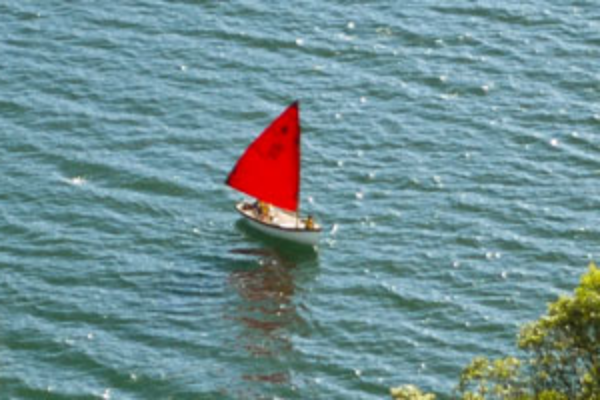

In [12]:
resized_cropped_region_2x = resized_cropped_region_2x[:, :, ::-1]

cv2.imwrite("resized_cropped_region_2x.png", resized_cropped_region_2x)

Image(filename="resized_cropped_region_2x.png")

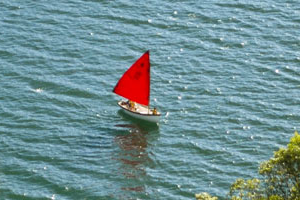

In [13]:
cropped_region = cropped_region[:, :, ::-1]

cv2.imwrite("cropped_region.png", cropped_region)

Image(filename="cropped_region.png")

## 画像の反転 

`cv2.flip(src, flipCode)`  
・src：入力画像  
・flipCode：反転形式を指定するコード。  
　0：上下反転、1：左右反転、-1：上下左右(180度)回転

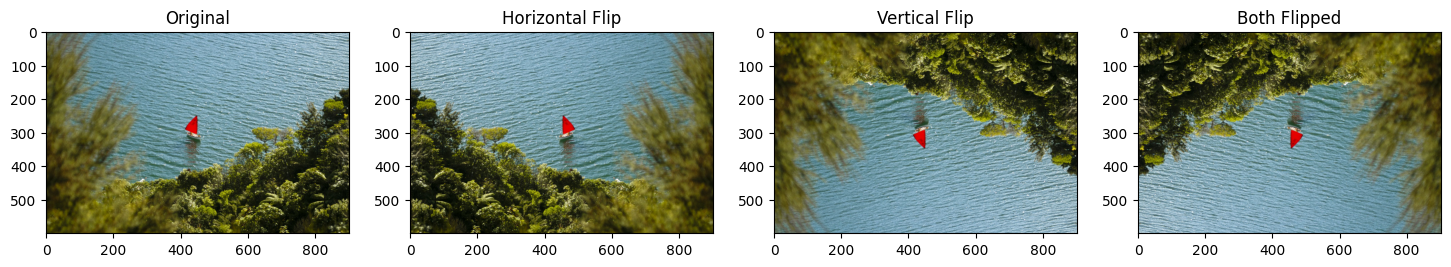

In [14]:
img_NZ_rgb_flipped_horz = cv2.flip(img_NZ_rgb, 1)
img_NZ_rgb_flipped_vert = cv2.flip(img_NZ_rgb, 0)
img_NZ_rgb_flipped_both = cv2.flip(img_NZ_rgb, -1)

plt.figure(figsize=(18, 5))
plt.subplot(141);plt.imshow(img_NZ_rgb);plt.title("Original");
plt.subplot(142);plt.imshow(img_NZ_rgb_flipped_horz);plt.title("Horizontal Flip");
plt.subplot(143);plt.imshow(img_NZ_rgb_flipped_vert);plt.title("Vertical Flip");
plt.subplot(144);plt.imshow(img_NZ_rgb_flipped_both);plt.title("Both Flipped");

## 画像への書き込み

・線の描画  
・円の描画  
・四角形の描画  
・テキストの追加  

物体検出をした時、画像に描画しないと以下のような数値が返ってくる。  
[[120, 45, 200, 180, 0.87], [310, 90, 380, 150, 0.62]]  
これだと非エンジニアが見ても何も伝わらないので、画像に描画してモデルが認識している箇所を可視化することは、非常に重要。
また、座標のバグを可視化するという意味でも、描画させた方が圧倒的にわかりやすい。

In [15]:
# 画像のダウンロード
URL = r"https://www.dropbox.com/s/48hboi1m4crv1tl/opencv_bootcamp_assets_NB3.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB3.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)  

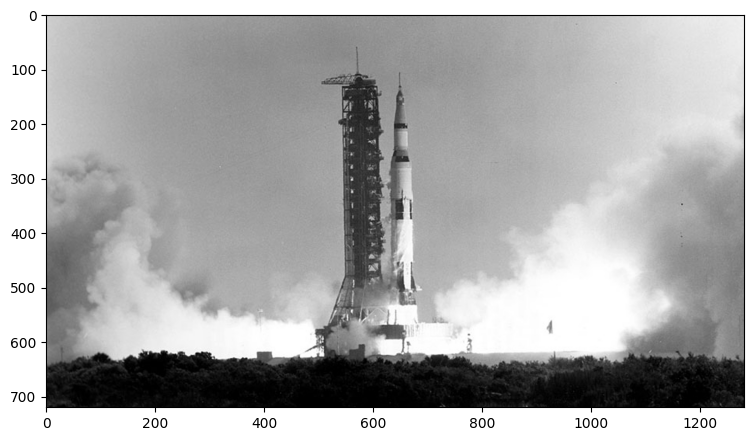

In [16]:
# 画像の読み込み
image = cv2.imread("Apollo_11_Launch.jpg", cv2.IMREAD_COLOR)

plt.imshow(image[:, :, ::-1])

## 線の描画

`cv2.line(img, pt1, pt2, color, thickness, lineType, shift)`  
必須の引数：
・img：入力画像  
・pt1：線の最初の点(x,y座標)  
・pt2：線の最後の点(x,y座標)  
・color：線の色  

任意の引数：
・thickness：線の太さ。デフォルトで1  
・lineType：線の種類。デフォルトで8(8-connectesd線)  

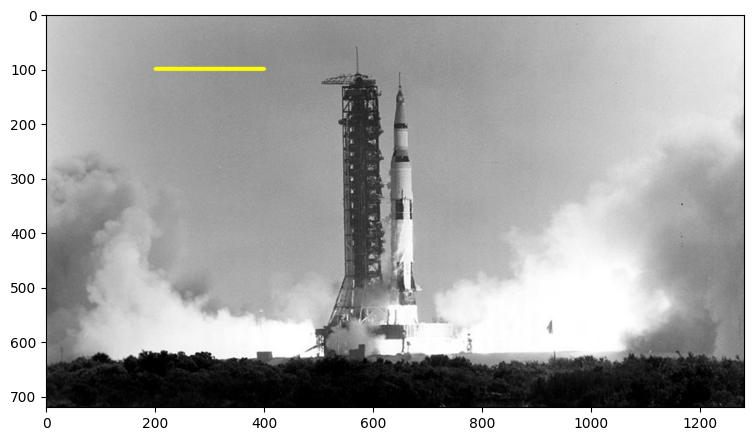

In [22]:
imageLine = image.copy()

cv2.line(imageLine, (200, 100), (400, 100), (0, 255, 255), thickness=5, lineType=cv2.LINE_AA);

plt.imshow(imageLine[:,:,::-1])

## 円の描画

`cv2.circle(img, center, radius, color, thickness, lineType)`
・img：入力画像  
・center：円の中心座標(x, y)  
・radius：円の半径  
・color：円の色  
・thickness（任意）：線の太さ。負の値を指定すると塗りつぶした円になる。    
・lineType（任意）：線の種類。 線の時と同様。

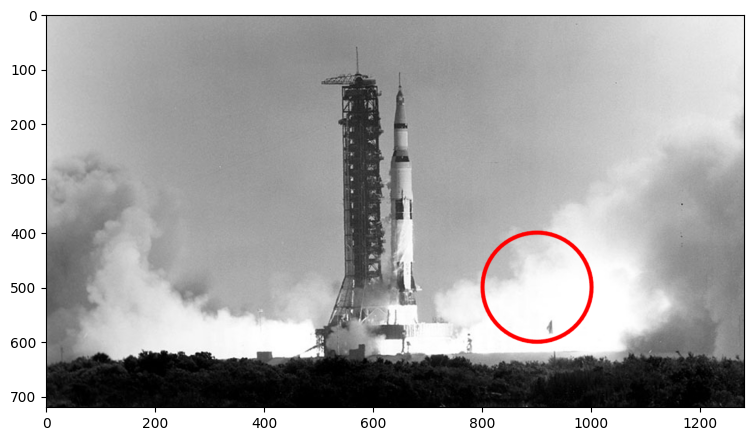

In [18]:
imageCircle = image.copy()

cv2.circle(imageCircle, (900,500), 100, (0, 0, 255), thickness=5, lineType=cv2.LINE_AA);

plt.imshow(imageCircle[:,:,::-1])

## 長方形の描画

`cv2.rectangle(img, pt1, pt2, color, thickness, lineType)`
・img：入力画像  
・pt1：長方形の左上の頂点(x,y座標)  
・pt2：pt1と対角(右下)にある頂点(x,y座標)  
・color：線の色  
・thickness（任意）：線の太さ。負の値を指定すると塗りつぶした円になる。  
・lineType（任意）：線の種類。線の時と同様。  

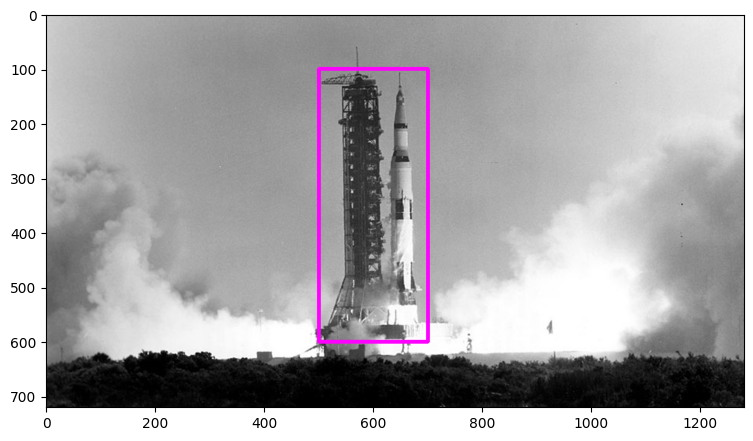

In [21]:
imageRectangle = image.copy()

cv2.rectangle(imageRectangle, (500, 100), (700, 600), (255, 0, 255), thickness=5, lineType=cv2.LINE_8)

plt.imshow(imageRectangle[:, :, ::-1])

## テキストの追加

`cv2.putText(img, text, org,  fontFace, fontScale, color, thickness, lineType)`  
・img：入力画像  
・text：書き込むテキスト  
・org：テキスト左端の座標(x, y)  
・fontFace：フォントの種類   
・fontScale：フォントの拡大率  
・color：フォントの色  
・thickness（任意）：線の太さ。デフォルトで1。  
・lineType（任意）：線の種類。線の時と同様。  

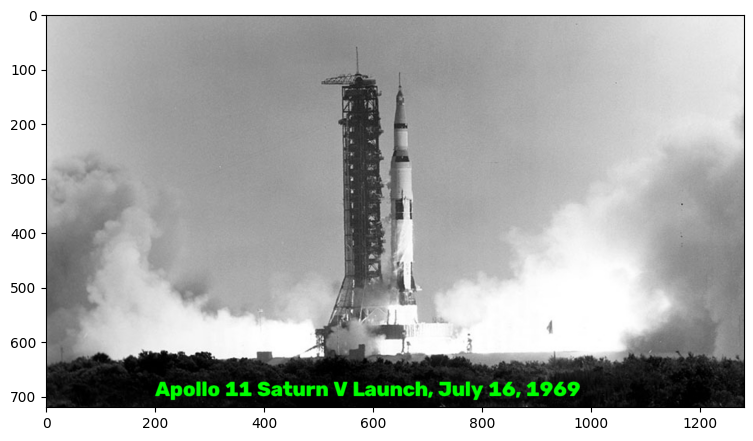

In [20]:
imageText = image.copy()
text = "Apollo 11 Saturn V Launch, July 16, 1969"
fontScale = 2.3
fontFace = cv2.FONT_HERSHEY_PLAIN
fontColor = (0, 255, 0)
fontThickness = 2

cv2.putText(imageText, text, (200, 700), fontFace, fontScale, fontColor, fontThickness, cv2.LINE_AA);

plt.imshow(imageText[:, :, ::-1])